# Indicators, levels, sizing rules and machine learning: do they work on our data?

The question from the person using RADAR: *"I don't know when to resize, or around
which prices to add or reduce. Traders use volatility, volume, moving averages, RSI,
support and resistance, order blocks, fair value gaps, upcoming news, and machine
learning. Can the app do that?"*

This notebook tests every one of those on Bitcoin, gold and US stocks before anything
is built. It has three parts:

| part | question | how it is judged |
|---|---|---|
| **A. How much to hold** | does a sizing rule do better than simply holding? | return per unit of risk, after costs |
| **B. Machine learning** | can a model call the next week's direction? | against always saying "up" |
| **C. Patterns and levels** | after an RSI extreme, a gap, a block, a level: what followed? | against what follows any day |

**The rules were written down before any result was computed**
(`docs/DECISIONS.md`, entry 060, committed on its own first). Every parameter is the
textbook one. Nothing was tuned.

## What earlier research found

| idea | finding | source |
|---|---|---|
| hold less when swings are high | raised return per unit of risk | Moreira & Muir, *Journal of Finance* 2017 |
| | versions usable in real time mostly did not beat holding | Cederburg and others, *J. Financial Economics* 2020 |
| the last 12 months' direction continues | yes, across 58 futures markets | Moskowitz, Ooi & Pedersen, *JFE* 2012 |
| | little evidence market by market | Huang, Li, Wang & Zhou, *JFE* 2020 |
| moving averages, range breaks | worked on 90 years of the Dow | Brock, Lakonishok & LeBaron, *J. Finance* 1992 |
| | the best rules failed once the number tried was allowed for | Sullivan, Timmermann & White, *J. Finance* 1999 |
| technical rules in general | 56 of 95 studies positive, most open to that problem | Park & Irwin, *J. Economic Surveys* 2007 |
| support and resistance | published levels did mark where intraday trends paused | Osler, *FRBNY Economic Policy Review* 2000 |
| the day before a Fed decision | US stocks rose | Lucca & Moench, *J. Finance* 2015 |
| | gone after 2015 | Kurov, Wolfe & Gilbert, 2021 |
| machine learning | a predictable part of about 0.4% of monthly movement, using 900 inputs and 30,000 stocks | Gu, Kelly & Xiu, *Review of Financial Studies* 2020 |
| order blocks, fair value gaps | no peer-reviewed test found | |
| trying many rules | one will look good by luck; allow for how many were tried | Bailey & Lopez de Prado, 2014 |

The pattern in that table: the first paper finds something, the later one finds less.

Rebuild with `uv run python backend/scripts/build_notebooks.py 11_direction_and_levels`.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import binomtest
from sklearn.exceptions import ConvergenceWarning

from radar.analytics import events
from radar.analytics import technical as ta
from radar.db.session import make_engine, session_scope
from radar.pipelines.datasets import load_field, stock_daily
from radar.signals import track
from radar.universe import get_universe

# The small network often stops at its step limit; part B says so in its text.
warnings.filterwarnings("ignore", category=ConvergenceWarning)
plt.rcParams.update({"figure.figsize": (11, 3.6), "axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.float_format", lambda v: f"{v:.3f}")
pd.set_option("display.width", 240)
pd.set_option("display.max_rows", 80)
engine, universe = make_engine(), get_universe()
NAMES = {"BTC/USD": "Bitcoin", "GLD": "Gold", "SPY": "US stocks"}
COLOURS = {"BTC/USD": "tab:orange", "GLD": "goldenrod", "SPY": "tab:blue"}
FIELDS = ["open", "high", "low", "close", "volume"]
DATES = sorted({d for kind in events.get_events() for d in kind.dates})

bars = {}
with session_scope(engine) as session:
    for asset in universe.primary:
        if asset.asset_class == "crypto":
            frame = pd.DataFrame({f: load_field(session, [asset.symbol], "1Day", f)[asset.symbol] for f in FIELDS})
            frame.index = pd.DatetimeIndex(frame.index).tz_localize(None)
        else:
            frame = pd.DataFrame({f: stock_daily(session, [asset.symbol], f)[asset.symbol] for f in FIELDS})
        bars[asset.symbol] = frame.dropna()
YEAR = {a.symbol: 365 if a.asset_class == "crypto" else 252 for a in universe.primary}
WEEK = {a.symbol: 7 if a.asset_class == "crypto" else 5 for a in universe.primary}
for symbol, frame in bars.items():
    print(f"{NAMES[symbol]:10s} {len(frame):5d} days, {frame.index[0].date()} to {frame.index[-1].date()}")

Bitcoin     2105 days, 2021-01-01 to 2026-10-06
Gold        2704 days, 2016-01-04 to 2026-10-05
US stocks   2704 days, 2016-01-04 to 2026-10-05


## 1. What each idea looks like

Before testing, the ideas drawn on the last 300 days of US stocks, so it is clear what
is being tested.

- **Moving averages**: the average close of the last 50 and 200 days.
- **RSI**: 100 when every recent day rose, 0 when every one fell. Under 30 is called
  "oversold", over 70 "overbought".
- **Support / resistance**: the lowest low and highest high of the last 60 days.
- **Fair value gap**: a day's low is above the high two days before (or the mirror),
  leaving a band no day traded through. The claim: price comes back to it and turns.
- **Order block**: the last falling day before a break to a new 20-day high (or the
  mirror). The claim: price comes back to that day's range and turns.

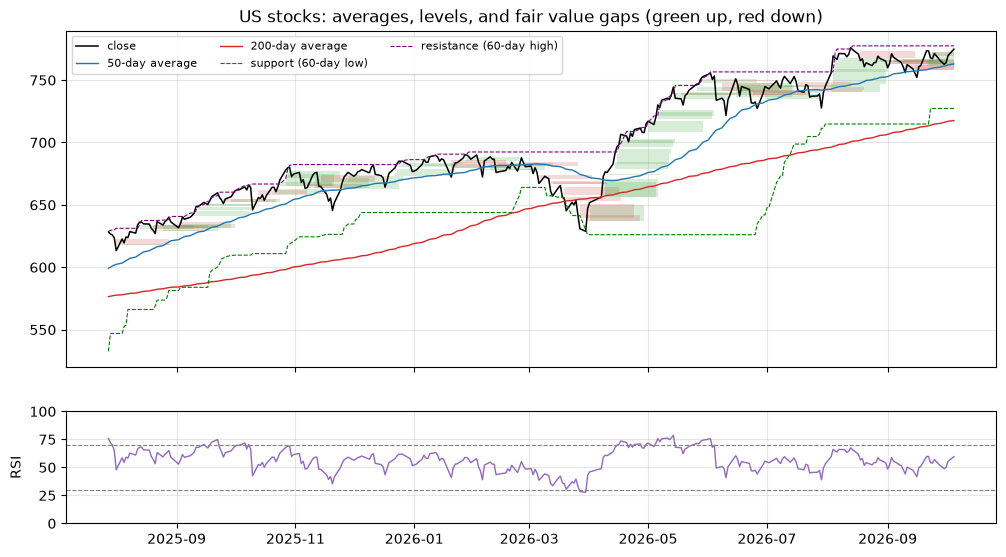

In [2]:
symbol = "SPY"
frame = bars[symbol]
view = frame.iloc[-300:]
close = frame["close"]
fig, (top, bottom) = plt.subplots(2, 1, figsize=(12, 6.4), sharex=True, height_ratios=[3, 1])
top.plot(view.index, view["close"], color="black", lw=1.1, label="close")
top.plot(view.index, ta.sma(close, 50).loc[view.index], color="tab:blue", lw=1, label="50-day average")
top.plot(view.index, ta.sma(close, 200).loc[view.index], color="tab:red", lw=1, label="200-day average")
top.plot(view.index, frame["low"].shift(1).rolling(60).min().loc[view.index], color="green", lw=0.8, ls="--", label="support (60-day low)")
top.plot(view.index, frame["high"].shift(1).rolling(60).max().loc[view.index], color="purple", lw=0.8, ls="--", label="resistance (60-day high)")
highs, lows = frame["high"].to_numpy(), frame["low"].to_numpy()
first = len(frame) - 300
for t in range(max(first, 2), len(frame)):
    if lows[t] > highs[t - 2]:
        top.fill_between(frame.index[t : t + 20], highs[t - 2], lows[t], color="tab:green", alpha=0.18, lw=0)
    if highs[t] < lows[t - 2]:
        top.fill_between(frame.index[t : t + 20], highs[t], lows[t - 2], color="tab:red", alpha=0.18, lw=0)
top.set(title=f"{NAMES[symbol]}: averages, levels, and fair value gaps (green up, red down)")
top.legend(fontsize=8, ncol=3)
reading = ta.rsi(close).loc[view.index]
bottom.plot(view.index, reading, color="tab:purple", lw=1)
bottom.axhline(70, color="grey", lw=0.8, ls="--")
bottom.axhline(30, color="grey", lw=0.8, ls="--")
bottom.set(ylabel="RSI", ylim=(0, 100));

## 2. First: can the models learn anything from this much data?

If nearly every test comes back "no measurable difference", a fair worry is that the
method is broken or the models were not trained properly. The way to find out is to
**plant a pattern on purpose** and see whether the same code finds it.

Below, the real inputs for US stocks are kept, but the answer is replaced by a made-up
one with a known rule: the week ends higher 65% of the time when the last 20 days rose,
and 40% of the time when they fell. That is a far stronger pattern than anything real
markets offer. A model that learns it should be right about 61% of the time; always
giving one answer is right about 57%.

In [3]:
symbol = "SPY"
plant_table = ta.features(bars[symbol], DATES)


def planted_answers(seed):
    rng = np.random.default_rng(seed)
    chance_up = np.where(plant_table["ret_20"] > 0, 0.65, 0.40)
    made_up = (rng.random(len(plant_table)) < chance_up).astype(float)
    return pd.Series(made_up, index=plant_table.index).where(plant_table["ret_20"].notna())


MODELS = {"trees, first settings": ta.fit_trees_heavy, "trees, kept small": ta.fit_trees, "small network": ta.fit_network}
rows = []
for name, fit in MODELS.items():
    scores = []
    for seed in (11, 12, 13):
        answers = planted_answers(seed)
        learned = ta.walk_forward(plant_table, answers, WEEK[symbol], fit)
        both = pd.DataFrame({"chance": learned, "rose": answers}).dropna().iloc[:: WEEK[symbol]]
        knows_rule = (plant_table["ret_20"].reindex(both.index) > 0) == (both["rose"] == 1)
        scores.append(
            (((both["chance"] > 0.5) == (both["rose"] == 1)).mean(), max(both["rose"].mean(), 1 - both["rose"].mean()), knows_rule.mean())
        )
    model, one_answer, rule = np.mean(scores, axis=0) * 100
    rows.append({"model": name, "right %": model, "always one answer %": one_answer, "knowing the rule %": rule, "of the possible gain %": (model - one_answer) / (rule - one_answer) * 100})
planted = pd.DataFrame(rows)
planted

,model,right %,always one answer %,knowing the rule %,of the possible gain %
0,"trees, first settings",57.545,57.118,60.614,12.195
1,"trees, kept small",60.443,57.118,60.614,95.122
2,small network,55.754,57.118,60.614,-39.024


Three things come out of this, and they matter for everything after.

1. **The first settings were wrong.** The trees as first set up (200 rounds, deeper
   trees) picked up about an eighth of a pattern that was planted for them to find.
   With a few thousand days they were fitting noise. That model was not trained
   properly, and a "no" from it would have meant nothing.
2. **Kept small, the trees work.** Fewer, shallower trees with larger groups picked up
   nearly all of it. These settings were chosen on the planted pattern only, never on
   real outcomes, and are the ones used below (decision 061).
3. **The neural network cannot learn even this.** It did worse than giving one answer
   every time, in every setting tried. That is not a verdict on neural networks; it is
   what a few thousand examples allow. Its results below are shown for completeness
   and **carry no weight**: a model that misses a planted pattern cannot tell us that
   a real one is absent. A larger network or a transformer needs more data still.

So the loop that trains and tests is sound, and from here on a "no" from the small
trees is a real "no" for patterns of that strength.

## 3. Part A: rules that set how much to hold

Each rule gives a share between nothing and everything, decided at the day's close and
held over the next day. Changing it costs 0.1% of what is traded. Cash earns nothing.

| rule | what it does |
|---|---|
| swings | hold less when the last 20 days swung more than usual |
| 200-day average | hold while the close is above it |
| 50 over 200 | hold while the 50-day average is above the 200-day |
| 12-month direction | hold while the close is above the close a year ago |
| event caution | hold half the day before and the day of a Fed, jobs, or inflation release |
| swings + 200-day | both together |
| trees, network | the two models of part B: hold when they say "up" |

Each is compared with holding everything throughout, over the same days.

In [4]:
STEPS = WEEK
chances = {}
for symbol, frame in bars.items():
    table = ta.features(frame, DATES)
    target = ta.rises(frame["close"], STEPS[symbol])
    chances[symbol] = {
        "trees": ta.walk_forward(table, target, STEPS[symbol], ta.fit_trees),
        "network": ta.walk_forward(table, target, STEPS[symbol], ta.fit_network),
    }
    print(NAMES[symbol], "forecasts from", chances[symbol]["trees"].first_valid_index().date())

Bitcoin forecasts from 2023-01-21


Gold forecasts from 2018-12-26


US stocks forecasts from 2018-12-26


In [5]:
def weights(symbol):
    frame = bars[symbol]
    close, returns = frame["close"], frame["close"].pct_change()
    swings = ta.hold_by_swings(returns)
    average = ta.hold_above_average(close)
    rules = {
        "swings": swings,
        "200-day average": average,
        "50 over 200": ta.hold_on_cross(close),
        "12-month direction": ta.hold_on_direction(close),
        "event caution": ta.hold_through_events(pd.DatetimeIndex(frame.index), DATES),
        "swings + 200-day": swings * average,
    }
    rules = {name: w.iloc[ta.WARM_UP :] for name, w in rules.items()}
    for name, chance in chances[symbol].items():
        rules[name] = (chance > 0.5).astype(float).where(chance.notna()).dropna()
    return rules


rows, curves = [], {}
for symbol, frame in bars.items():
    returns = frame["close"].pct_change()
    curves[symbol] = {}
    for name, weight in weights(symbol).items():
        days = weight.index
        rule = ta.backtest(returns.loc[days], weight)
        hold = ta.backtest(returns.loc[days], pd.Series(1.0, index=days))
        gap, p_value = ta.sharpe_difference(rule, hold, YEAR[symbol])
        curves[symbol][name] = rule
        curves[symbol].setdefault("hold" if name not in chances[symbol] else "hold (model days)", hold)
        years = len(rule) / YEAR[symbol]
        rows.append(
            {
                "market": NAMES[symbol],
                "rule": name,
                "days": len(rule),
                "Sharpe": ta.sharpe(rule, YEAR[symbol]),
                "holding": ta.sharpe(hold, YEAR[symbol]),
                "difference": gap,
                "p": p_value,
                "return/yr %": ((1 + rule).prod() ** (1 / years) - 1) * 100,
                "holding ret/yr %": ((1 + hold).prod() ** (1 / years) - 1) * 100,
                "deepest fall %": ta.deepest_fall(rule) * 100,
                "holding fall %": ta.deepest_fall(hold) * 100,
                "time held %": weight.shift(1).reindex(rule.index).mean() * 100,
            }
        )
sizing = pd.DataFrame(rows)
passing = track.survivors([(i, 0, p) for i, p in enumerate(sizing["p"])], 0.05)
sizing["survives"] = [(i, 0) in passing for i in range(len(sizing))]
sizing["verdict"] = np.where(
    sizing["survives"] & (sizing["difference"] > 0),
    "does better",
    np.where(sizing["survives"], "does worse", "no measurable difference"),
)
sizing

,market,rule,days,Sharpe,holding,difference,p,return/yr %,holding ret/yr %,deepest fall %,holding fall %,time held %,survives,verdict
0,Bitcoin,swings,1852,0.499,0.504,-0.005,0.841,13.254,13.552,-75.323,-76.673,96.298,False,no measurable difference
1,Bitcoin,200-day average,1852,0.759,0.504,0.255,0.458,22.969,13.552,-36.195,-76.673,53.564,False,no measurable difference
2,Bitcoin,50 over 200,1852,0.500,0.504,-0.004,0.993,12.370,13.552,-44.638,-76.673,53.456,False,no measurable difference
3,Bitcoin,12-month direction,1852,0.811,0.504,0.307,0.348,27.557,13.552,-43.730,-76.673,64.201,False,no measurable difference
4,Bitcoin,event caution,1852,0.489,0.504,-0.015,0.857,12.680,13.552,-73.369,-76.673,91.442,False,no measurable difference
5,Bitcoin,swings + 200-day,1852,0.778,0.504,0.274,0.422,23.250,13.552,-36.178,-76.673,52.287,False,no measurable difference
6,Bitcoin,trees,1354,0.829,0.999,-0.169,0.645,24.389,42.817,-43.222,-53.087,47.341,False,no measurable difference
7,Bitcoin,network,1354,0.654,0.999,-0.344,0.461,16.280,42.817,-38.342,-53.087,42.171,False,no measurable difference
8,Gold,swings,2451,0.925,0.848,0.078,0.413,11.007,13.516,-19.733,-26.405,82.856,False,no measurable difference
9,Gold,200-day average,2451,0.591,0.848,-0.256,0.106,7.829,13.516,-32.535,-26.405,71.603,False,no measurable difference


**How to read it.** *Sharpe* is return per unit of risk; *difference* is the rule's
minus holding's. *p* is how often a difference this large would appear by luck; a rule
"does better" only if that survives allowing for all 24 comparisons made here.
*Deepest fall* is the worst drop from a high, which is what a person actually feels.

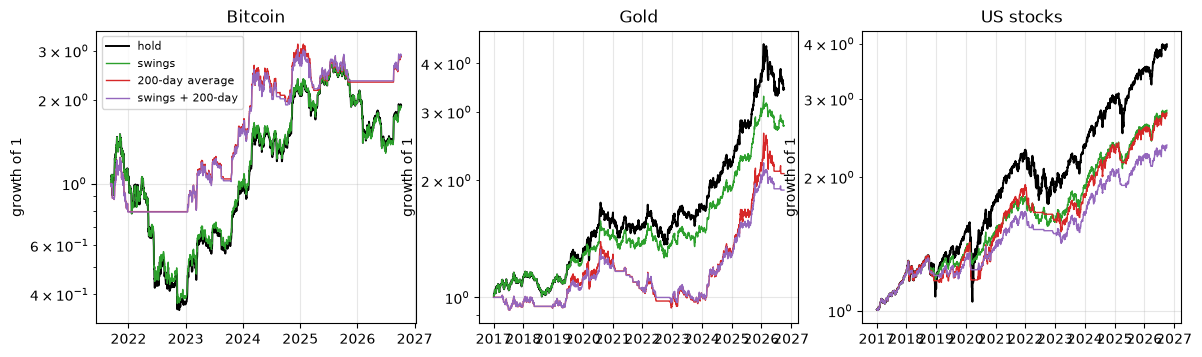

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
SHOW = {"hold": ("black", 1.4), "swings": ("tab:green", 1), "200-day average": ("tab:red", 1), "swings + 200-day": ("tab:purple", 1)}
for ax, symbol in zip(axes, bars):
    for name, (colour, width) in SHOW.items():
        series = curves[symbol][name]
        ax.plot(series.index, (1 + series).cumprod(), color=colour, lw=width, label=name)
    ax.set(title=NAMES[symbol], yscale="log", ylabel="growth of 1")
axes[0].legend(fontsize=8);

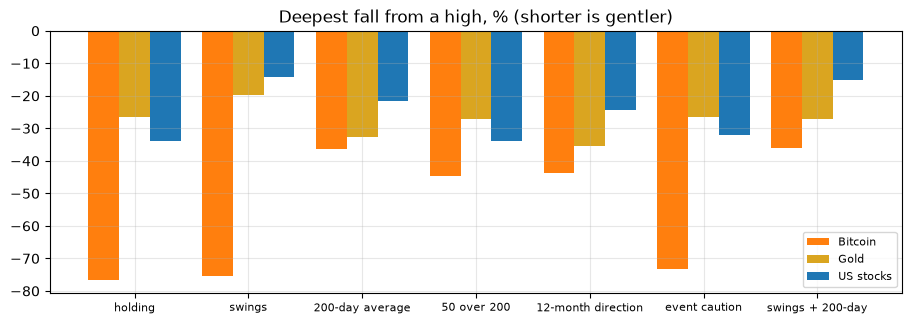

In [7]:
pivot_fall = sizing.pivot(index="rule", columns="market", values="deepest fall %")
hold_fall = sizing.groupby("market")["holding fall %"].first()
order = ["swings", "200-day average", "50 over 200", "12-month direction", "event caution", "swings + 200-day"]
fig, ax = plt.subplots(figsize=(11, 3.4))
x = np.arange(len(order) + 1)
for i, symbol in enumerate(bars):
    name = NAMES[symbol]
    values = [hold_fall[name]] + [pivot_fall.loc[rule, name] for rule in order]
    ax.bar(x + (i - 1) * 0.27, values, width=0.27, color=COLOURS[symbol], label=name)
ax.set_xticks(x, ["holding"] + order, fontsize=8)
ax.set(title="Deepest fall from a high, % (shorter is gentler)")
ax.legend(fontsize=8);

In [8]:
summary = (
    sizing.assign(
        gentler=sizing["deepest fall %"] > sizing["holding fall %"],
        earned_less=sizing["return/yr %"] < sizing["holding ret/yr %"],
    )
    .groupby("rule")
    .agg(
        better=("verdict", lambda v: (v == "does better").sum()),
        worse=("verdict", lambda v: (v == "does worse").sum()),
        gentler_fall=("gentler", "sum"),
        earned_less=("earned_less", "sum"),
        avg_difference=("difference", "mean"),
    )
)
print("Out of 3 markets, how many times each rule...")
summary

Out of 3 markets, how many times each rule...


,better,worse,gentler_fall,earned_less,avg_difference
rule,,,,,
12-month direction,0,0,2,2,0.003
200-day average,0,0,2,2,0.018
50 over 200,0,0,2,3,-0.108
event caution,0,1,2,3,-0.143
network,0,0,3,3,-0.432
swings,0,0,3,3,0.083
swings + 200-day,0,0,2,2,0.070
trees,0,0,2,3,-0.221


### What part A shows

**No rule did better than holding, on return per unit of risk, in any market.** Not
one of the 24 comparisons survives. One did measurably *worse*: stepping back around
scheduled events in gold.

But return per unit of risk is not the only thing a person cares about. Look at the
deepest fall:

- **Bitcoin:** holding fell about 77% from its high. The 200-day rule fell about 36%,
  and happened to earn more too (that part cannot be told apart from luck).
- **US stocks:** holding fell about 34%. Sizing by swings fell about 14%, and earned
  about 4 points a year less.
- **Gold:** the trend rules made the deepest fall *worse*, and every rule earned less.
  Gold rose steadily for most of this period, so any rule that steps aside missed part
  of it.

So these rules are not a way to earn more. In two of three markets they were a way to
fall less far, paid for with part of the return. That is a trade a person can choose
to make, and it is honest to show it as one. In the third market it did not even do
that, which is the warning: **it depends on the period**, and ten years is one period.

Stepping back around scheduled events did nothing useful anywhere.

## 4. Part B: can a model call the direction?

Two models, both from scikit-learn: gradient-boosted trees and a small neural network.
Each is given 14 things known at the close (recent returns, RSI, distance from the
averages, swings, volume, distance from the year's high and low, days to the next
scheduled event) and asked: *will the close be higher a week from now?*

They are refitted every 63 days on every earlier day whose outcome was already known,
and never see a later day. Accuracy is counted on weeks that do not overlap, and set
against the laziest forecast there is: **always say "up"**.

In [9]:
rows = []
for symbol, frame in bars.items():
    target = ta.rises(frame["close"], STEPS[symbol])
    for name, chance in chances[symbol].items():
        both = pd.DataFrame({"chance": chance, "rose": target}).dropna().iloc[:: STEPS[symbol]]
        said_up = both["chance"] > 0.5
        right = int((said_up == (both["rose"] == 1)).sum())
        n = len(both)
        always_up = both["rose"].mean()
        rows.append(
            {
                "market": NAMES[symbol],
                "model": name,
                "weeks": n,
                "accuracy %": right / n * 100,
                "always 'up' %": always_up * 100,
                "said up %": said_up.mean() * 100,
                "p (better than always up)": binomtest(right, n, max(always_up, 1 - always_up), alternative="greater").pvalue,
            }
        )
accuracy = pd.DataFrame(rows)
accuracy

,market,model,weeks,accuracy %,always 'up' %,said up %,p (better than always up)
0,Bitcoin,trees,193,54.404,53.368,49.223,0.415
1,Bitcoin,network,193,48.187,53.368,39.896,0.935
2,Gold,trees,390,53.077,58.718,68.718,0.989
3,Gold,network,390,52.308,58.718,50.513,0.995
4,US stocks,trees,390,60.000,61.026,94.872,0.681
5,US stocks,network,390,53.590,61.026,63.333,0.999


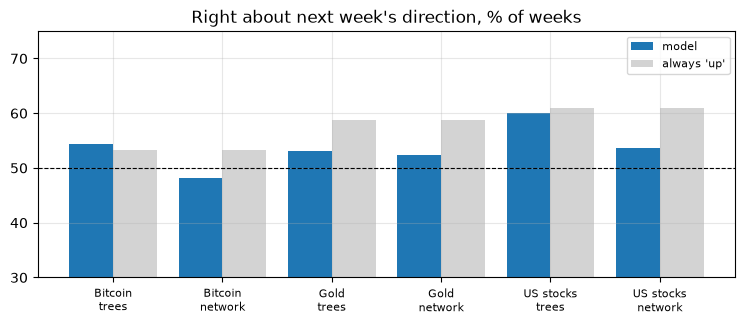

In [10]:
fig, ax = plt.subplots(figsize=(9, 3.2))
x = np.arange(len(accuracy))
ax.bar(x - 0.2, accuracy["accuracy %"], width=0.4, color="tab:blue", label="model")
ax.bar(x + 0.2, accuracy["always 'up' %"], width=0.4, color="lightgrey", label="always 'up'")
ax.axhline(50, color="black", lw=0.8, ls="--")
ax.set_xticks(x, [f"{m}\n{k}" for m, k in zip(accuracy["market"], accuracy["model"])], fontsize=8)
ax.set(title="Right about next week's direction, % of weeks", ylim=(30, 75))
ax.legend(fontsize=8);

### What part B shows

**The trees, which section 2 showed can learn, did not beat always saying "up" in any
market.**

- **Bitcoin:** right in about 54% of weeks, against 53% for always "up". Within luck.
- **US stocks:** right in 60%, against 61%. It said "up" in about 95% of weeks: what it
  learned from ten years of US stocks is "they usually go up", which is true and is
  not a forecast.
- **Gold:** right in 53%, against 59%. Worse than always "up".

The network's row is there for completeness; section 2 showed it cannot learn from
this much data, so it tells us nothing either way.

This matches the research. The largest study found a predictable part of well under
1% of the movement, using hundreds of inputs and tens of thousands of stocks. The
planted pattern in section 2 was a 25-point difference; anything real is a small
fraction of that. The model is working. There is very little there for it to find in
daily prices of one market, and a bigger model does not change what is there.

The rows for "trees" and "network" in the table of part A show the same models used as
a sizing rule: hold when the model says "up", cash when it does not.

## 5. Part C: patterns and levels

For each pattern, every past case is found, and the share of cases followed by a rise
over the next week is compared with the same share for **any** day. This is the method
already used for RADAR's signals (decision 051): at least 30 cases, a plausible range
for the share that leaves out the any-day share, and a result that survives allowing
for all 33 comparisons made here.

In [11]:
def cases(symbol):
    frame = bars[symbol]
    high, low, close, volume = frame["high"], frame["low"], frame["close"], frame["volume"]
    return {
        "RSI under 30": ta.rsi_cases(close, below=True),
        "RSI over 70": ta.rsi_cases(close, below=False),
        "fair value gap, up": ta.fair_value_gap_cases(high, low, up=True),
        "fair value gap, down": ta.fair_value_gap_cases(high, low, up=False),
        "order block, up": ta.order_block_cases(frame, up=True),
        "order block, down": ta.order_block_cases(frame, up=False),
        "at support": ta.support_cases(low),
        "at resistance": ta.resistance_cases(high),
        "new 252-day high": ta.new_high_cases(close),
        "high volume, rising day": ta.high_volume_cases(close, volume, rising=True),
        "high volume, falling day": ta.high_volume_cases(close, volume, rising=False),
    }


CLAIM = {
    "RSI under 30": "rise", "RSI over 70": "fall", "fair value gap, up": "rise", "fair value gap, down": "fall",
    "order block, up": "rise", "order block, down": "fall", "at support": "rise", "at resistance": "fall",
    "new 252-day high": "rise", "high volume, rising day": "rise", "high volume, falling day": "fall",
}
records = []
for symbol, frame in bars.items():
    for name, days in cases(symbol).items():
        records.append(track.record("pattern", symbol, name, days, frame["close"], [(STEPS[symbol], "1 week")]))
records = track.correct_family(records)
rows = []
for r in records:
    h = r.horizons[0]
    rows.append(
        {
            "market": NAMES[r.symbol],
            "pattern": r.variant,
            "claimed": CLAIM[r.variant],
            "cases": r.n,
            "rose after %": None if h.signal.share_positive is None else h.signal.share_positive * 100,
            "range low": None if h.signal.share_low is None else h.signal.share_low * 100,
            "range high": None if h.signal.share_high is None else h.signal.share_high * 100,
            "any day %": h.baseline.share_positive * 100,
            "p": h.p_value,
            "direction": h.verdict,
            "typical move %": None if h.signal.mean_size is None else h.signal.mean_size * 100,
            "any day move %": h.baseline.mean_size * 100,
            "size": h.size_verdict,
        }
    )
patterns = pd.DataFrame(rows)
patterns

,market,pattern,claimed,cases,rose after %,range low,range high,any day %,p,direction,typical move %,any day move %,size
0,Bitcoin,RSI under 30,rise,78,57.692,46.622,68.041,51.811,0.310,no measurable edge,5.269,5.623,no measurable difference
1,Bitcoin,RSI over 70,fall,192,60.417,53.360,67.064,51.811,0.017,no measurable edge,5.537,5.623,no measurable difference
2,Bitcoin,"fair value gap, up",rise,164,43.293,35.949,50.944,51.811,0.035,no measurable edge,5.310,5.623,no measurable difference
3,Bitcoin,"fair value gap, down",fall,155,55.484,47.621,63.081,51.811,0.377,no measurable edge,6.112,5.623,no measurable difference
4,Bitcoin,"order block, up",rise,62,54.839,42.533,66.580,51.811,0.704,no measurable edge,5.584,5.623,no measurable difference
5,Bitcoin,"order block, down",fall,36,58.333,42.200,72.859,51.811,0.506,no measurable edge,7.047,5.623,no measurable difference
6,Bitcoin,at support,rise,81,48.148,37.600,58.864,51.811,0.579,no measurable edge,7.078,5.623,followed by larger moves
7,Bitcoin,at resistance,fall,203,53.465,46.586,60.215,51.811,0.673,no measurable edge,5.423,5.623,no measurable difference
8,Bitcoin,new 252-day high,rise,91,49.451,39.411,59.535,51.811,0.676,no measurable edge,5.218,5.623,no measurable difference
9,Bitcoin,"high volume, rising day",rise,77,54.545,43.473,65.186,51.811,0.650,no measurable edge,6.300,5.623,no measurable difference


**The same table as a picture.** Each dot is how often the market rose in the week
after the pattern. The bar through it is the range that share could plausibly lie in.
The black line is the same share for any day. **A bar that crosses the line means the
pattern told you nothing.** Grey dots have fewer than 30 cases.

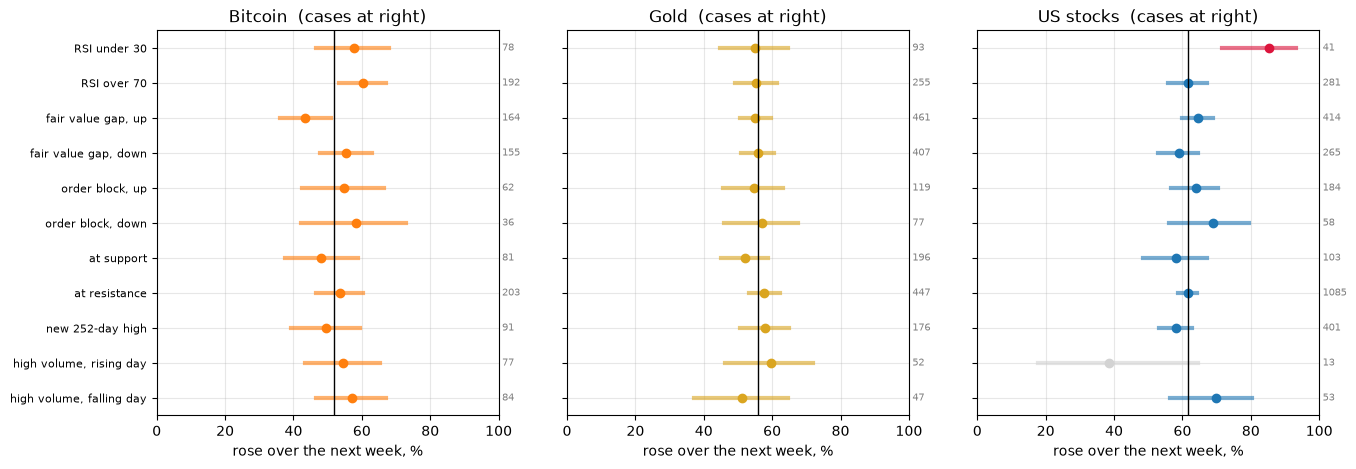

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
names = list(CLAIM)
for ax, symbol in zip(axes, bars):
    part = patterns[patterns["market"] == NAMES[symbol]].set_index("pattern").loc[names]
    y = np.arange(len(names))[::-1]
    for yi, (_, row) in zip(y, part.iterrows()):
        if pd.isna(row["rose after %"]):
            continue
        found = row["direction"] in ("followed by rises more often", "followed by falls more often")
        colour = "lightgrey" if row["cases"] < 30 else ("crimson" if found else COLOURS[symbol])
        ax.plot([row["range low"], row["range high"]], [yi, yi], color=colour, lw=3, alpha=0.6)
        ax.plot(row["rose after %"], yi, "o", color=colour)
        ax.text(101, yi, f"{int(row['cases'])}", va="center", fontsize=7, color="grey")
    ax.axvline(part["any day %"].iloc[0], color="black", lw=1)
    ax.set(title=f"{NAMES[symbol]}  (cases at right)", xlim=(0, 100), xlabel="rose over the next week, %")
    ax.set_yticks(y, names, fontsize=8)

In [13]:
found = patterns[patterns["direction"].isin(["followed by rises more often", "followed by falls more often"])]
sized = patterns[patterns["size"].isin(["followed by larger moves", "followed by smaller moves"])]
print(f"Direction: {len(found)} of {len(patterns)} comparisons stand out after correction.")
print(found[["market", "pattern", "claimed", "cases", "rose after %", "any day %", "direction"]].to_string(index=False) if len(found) else "  none")
print(f"\nSize of the move: {len(sized)} of {len(patterns)} stand out after correction.")
print(sized[["market", "pattern", "cases", "typical move %", "any day move %", "size"]].to_string(index=False) if len(sized) else "  none")

Direction: 1 of 33 comparisons stand out after correction.
   market      pattern claimed  cases  rose after %  any day %                    direction
US stocks RSI under 30    rise     41        85.366     61.690 followed by rises more often

Size of the move: 12 of 33 stand out after correction.
   market                  pattern  cases  typical move %  any day move %                      size
  Bitcoin               at support     81           7.078           5.623  followed by larger moves
     Gold              RSI over 70    255           2.212           1.696  followed by larger moves
     Gold         new 252-day high    176           2.632           1.696  followed by larger moves
     Gold  high volume, rising day     52           2.940           1.696  followed by larger moves
US stocks             RSI under 30     41           3.661           1.618  followed by larger moves
US stocks              RSI over 70    281           0.964           1.618 followed by smaller moves
U

### A check on the one finding (added after seeing the result)

One pattern stands out on direction: **US stocks after RSI under 30**. The rule was
written as "days the RSI closed under 30", and such days come in runs: one sharp
sell-off can supply ten of them. The test above counts each day as a separate case,
which flatters it. So here each run is counted once, on its first day. This check was
not in the written rules; it is here because the finding needed it.

In [14]:
symbol = "SPY"
close = bars[symbol]["close"]
days = pd.DatetimeIndex(ta.rsi_cases(close, below=True))
rows_of = np.array([close.index.get_loc(d) for d in days])
first_of_run = np.insert(np.diff(rows_of) > STEPS[symbol], 0, True)
forward = track.forward_returns(close, STEPS[symbol])
episodes = pd.DataFrame(
    {"first day": days[first_of_run].date, "next week %": forward.loc[days[first_of_run]].to_numpy() * 100}
)
episodes["rose"] = episodes["next week %"] > 0
low, high = track.wilson(int(episodes["rose"].sum()), len(episodes))
any_day = forward.gt(0).sum() / forward.notna().sum()
print(f"{len(days)} days under 30 came from {len(episodes)} separate sell-offs.")
print(
    f"Rose in the week after the first day: {int(episodes['rose'].sum())} of {len(episodes)}; "
    f"plausible range {low:.0%} to {high:.0%}; any day {any_day:.0%}."
)
print("Range covers the any-day figure:", bool(low <= any_day <= high))
episodes

41 days under 30 came from 15 separate sell-offs.
Rose in the week after the first day: 11 of 15; plausible range 48% to 89%; any day 62%.
Range covers the any-day figure: True


,first day,next week %,rose
0,2016-11-03,3.806,True
1,2018-02-05,0.455,True
2,2018-10-10,0.771,True
3,2018-10-24,2.045,True
4,2018-12-19,-0.554,False
5,2019-08-05,1.355,True
6,2020-02-25,-4.006,False
7,2020-03-09,-13.648,False
8,2022-01-21,0.903,True
9,2022-09-23,-2.972,False


Counted as separate sell-offs, the finding does not hold. The 41 days were 15
sell-offs, and the market rose in the week after 11 of them. With 15 cases the
plausible range for that share runs from about half to about nine in ten, which
covers the any-day figure of 62%. The 85% came from counting the same few rebounds
many times, and the misses include February and March 2020, when the fall carried
on. **Treat "US stocks rise after RSI under 30" as not shown.**

### What part C shows

**On direction: nothing that holds up.** Fair value gaps, order blocks, support,
resistance, new highs, high volume, and RSI did not tell which way the next week went,
in any market. For Bitcoin, the return to an up-gap was followed by a rise *less*
often than any day, the opposite of the claim, though not by enough to count.

**On the size of the move: a consistent picture.** In US stocks, moves were larger
than usual after touching support, after down-gaps and down-blocks, after RSI under
30, and after heavy volume on a falling day. They were *smaller* than usual at
resistance, at new highs, and with RSI over 70. In plain words: **after falls the
market is rougher; near highs it is calmer.** That is a known feature of stock
markets, and it is the same thing RADAR's swings forecast already picks up. These
patterns are different names for "it has just fallen" or "it has just risen".
The same caution applies as above: these cases also come in runs.

## Can the pattern test find something when it is there?

The same question as in section 2, for the test used in this part. A made-up price is
built in which the week after "the last 20 days rose" ends higher more often than
other weeks, and the unchanged test is run on it. Then: how small an edge could this
test see at all, for a given number of cases?

In [15]:
symbol = "SPY"
steps = STEPS[symbol]
answers = planted_answers(11)
move = np.where(answers.fillna(0) == 1, 0.01, -0.01)
fake_close = pd.Series(100 * np.exp(np.cumsum(move / steps)), index=plant_table.index)
case_days = list(plant_table.index[(plant_table["ret_20"] > 0).to_numpy()][::steps])
found_it = track.correct_family([track.record("planted", symbol, "last 20 days rose", case_days, fake_close, [(steps, "1 week")])])[0].horizons[0]
print(
    f"Planted pattern: {found_it.signal.n} cases, rose after {found_it.signal.share_positive:.0%} "
    f"(range {found_it.signal.share_low:.0%} to {found_it.signal.share_high:.0%}), any day {found_it.baseline.share_positive:.0%} -> {found_it.verdict}"
)
rows = []
for n in (40, 100, 200, 400, 1000):
    low, high = track.wilson(round(0.55 * n), n)
    rows.append({"cases": n, "range around a 55% share": f"{low:.0%} to {high:.0%}", "smallest edge it can see, points": (high - low) / 2 * 100})
pd.DataFrame(rows)

Planted pattern: 377 cases, rose after 77% (range 73% to 81%), any day 65% -> followed by rises more often


,cases,range around a 55% share,"smallest edge it can see, points"
0,40,40% to 69%,14.733
1,100,45% to 64%,9.570
2,200,48% to 62%,6.830
3,400,50% to 60%,4.852
4,1000,52% to 58%,3.078


Two things to take from this.

**The test finds a pattern when there is one.** So the many "no measurable edge"
verdicts above are not a broken test.

**But it can only see large edges.** With 100 cases, anything under about 10 points
(say 62% against 52%) is invisible; with 400 cases, anything under about 5. Real edges
in liquid markets, where they exist, are a point or two. Seeing one of those would
take thousands of separate cases, which three markets and ten years do not contain.

That is the honest meaning of "no measurable difference" throughout RADAR: **not
"there is nothing", but "if there is something, it is smaller than this data can
show"**. And an edge too small to see in ten years is also too small for one person
to rely on.

## 6. The result, and my guess checked

| what was tested | result |
|---|---|
| 8 sizing rules x 3 markets, on return per unit of risk | 0 better, 1 worse |
| the same rules, on the deepest fall | much shallower in Bitcoin and US stocks, not in gold; less return in most |
| the model that can learn x 3 markets, against always "up" | 0 better |
| the neural network | cannot learn from this much data; no verdict |
| 11 patterns x 3 markets, on direction | 1 stood out, and did not hold when its runs were counted once |
| the same, on the size of the move | 12 stood out: rougher after falls, calmer near highs |

**What I guessed beforehand (decision 060), against what happened:**

- *Sizing by swings and the trend rules cut the deepest fall, with no gain in return
  per unit of risk that survives.* Right for Bitcoin and US stocks. **Wrong for gold**,
  where the trend rules made the fall deeper.
- *No pattern survives on direction.* One did by the written rule and did not hold
  when its runs were counted once. Right in substance, but the written rule was too
  loose: it should have counted runs once from the start.
- *High volume may be followed by larger moves.* Yes, in gold and US stocks.
- *Both models about as good as always "up".* Yes for the trees, and worse in gold.
  I did not expect the first settings to be unable to learn at all; the planted
  pattern caught that.

## 7. What this means for the app

The honest answer to "where do I add, where do I reduce" is that **no indicator here
reliably tells which way the price goes next**, including the two that have no
research behind them at all. Showing a "buy zone" would be showing something that was
tested and did not hold.

What the tests do support:

1. **A sizing guide, shown as a trade-off.** "Holding less when swings are high would
   have cut the deepest fall in US stocks from about 34% to 14%, and cost about 4
   points of return a year." The person chooses; the app shows both sides, and says it
   did not work for gold.
2. **Levels as places where the move gets bigger, not where it turns.** "Price is near
   its 60-day low. In the past, weeks that started there moved about twice as much as
   usual, in either direction."
3. **The expected range**, which the app already has and which holds up in its
   backtest: a low and a high for the next week.

All three answer "how much" and "how rough", which can be measured. None answers
"which way", which could not.

**Limits.** Six to eleven years, three markets, daily bars. A rule that failed here is
not proved useless everywhere; it was not detectable on this data. Nothing here was
tuned, and nothing should be: trying other parameters until one works is exactly the
mistake the 1999 and 2014 papers describe.

## 8. What a person could be shown today

Whatever the verdicts above, these readings exist and can be shown *with their
record*. This is what the newest day looks like for each market: the share the swings
rule would hold, which side of the 200-day average the price is on, and the nearest
levels below and above.

In [16]:
rows = []
for symbol, frame in bars.items():
    close, returns = frame["close"], frame["close"].pct_change()
    last = close.iloc[-1]
    rows.append(
        {
            "market": NAMES[symbol],
            "day": frame.index[-1].date(),
            "close": last,
            "swings: share to hold %": ta.hold_by_swings(returns).iloc[-1] * 100,
            "vs 200-day average %": (last / ta.sma(close, 200).iloc[-1] - 1) * 100,
            "RSI": ta.rsi(close).iloc[-1],
            "60-day low (support)": frame["low"].iloc[-60:].min(),
            "below close %": (frame["low"].iloc[-60:].min() / last - 1) * 100,
            "60-day high (resistance)": frame["high"].iloc[-60:].max(),
            "above close %": (frame["high"].iloc[-60:].max() / last - 1) * 100,
        }
    )
pd.DataFrame(rows)

,market,day,close,swings: share to hold %,vs 200-day average %,RSI,60-day low (support),below close %,60-day high (resistance),above close %
0,Bitcoin,2026-10-06,85542.050,100.000,19.378,63.455,62490.000,-26.948,87446.700,2.227
1,Gold,2026-10-05,379.550,63.129,-8.778,38.417,363.600,-4.202,429.420,13.139
2,US stocks,2026-10-05,774.830,100.000,7.983,59.602,727.290,-6.136,777.440,0.337
